# CNN FASHION MNIST

In [34]:
# import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# load images
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# Also check the shape of train and test images and labels
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


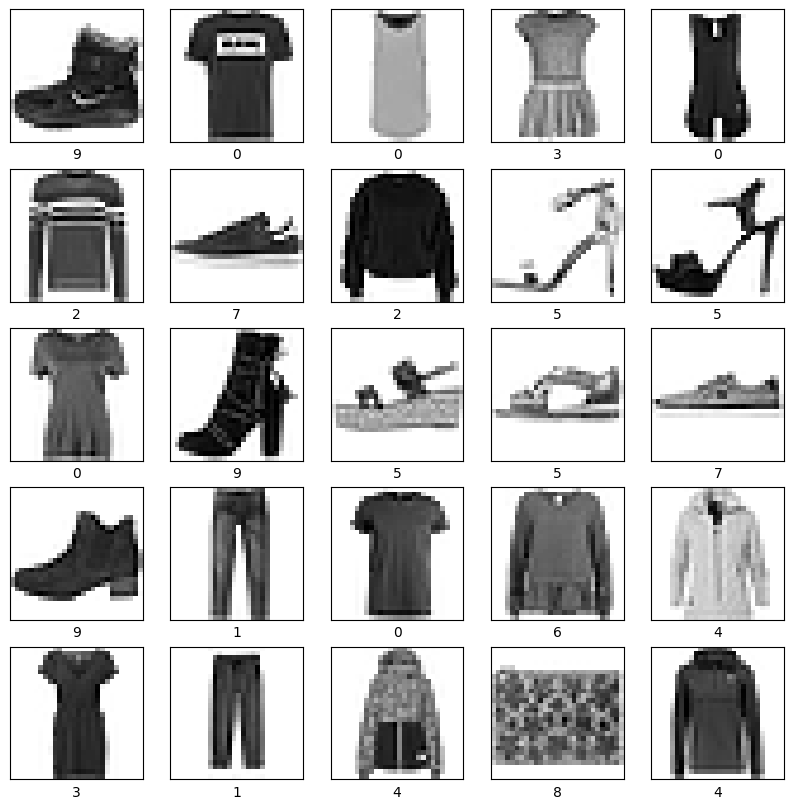

In [4]:
# Display SOme Images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
plt.show()

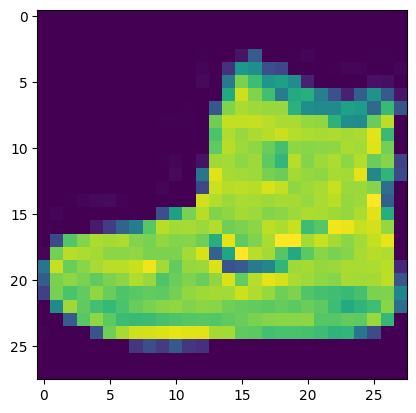

In [6]:
# Let see first image
plt.imshow(train_images[0])

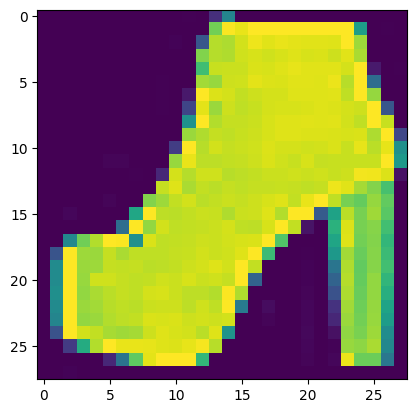

In [8]:
plt.imshow(train_images[44])


In [7]:
# Define CLass Names 
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

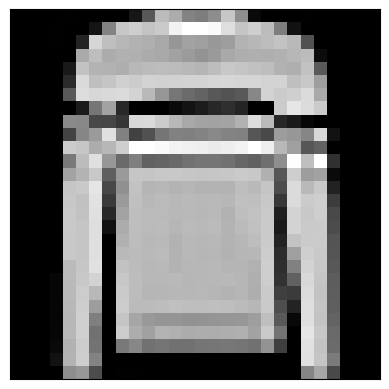

pixel values
   0    0    0    0    1    0    0    0    0   22   88  188  172  132  125  141  199  143    9    0    0    0    1    0    0    0    0    0 
   0    0    0    1    0    0   20  131  199  206  196  202  242  255  255  250  222  197  206  188  126   17    0    0    0    0    0    0 
   0    0    0    1    0   35  214  191  183  178  175  168  150  162  159  152  158  179  183  189  195  185   82    0    0    0    0    0 
   0    0    0    0    0  170  190  172  177  176  171  169  162  155  148  154  169  174  175  175  177  183  188   12    0    0    0    0 
   0    0    0    0   25  194  180  178  174  184  187  189  187  184  181  189  200  197  193  190  178  175  194   90    0    0    0    0 
   0    0    0    0   42  218  191  197  208  204  211  209  210  212  211  214  215  213  214  211  211  191  200  158    0    0    0    0 
   0    0    0    0   88  221  215  217  219  211  185  150  118  107   99   88   83   90  135  212  203  207  219  169    0    0    0    0 


In [16]:
# Display the fifth image in data set as a data matrix
plt.imshow(train_images[5],cmap='gray')
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()


# Display the values f each pixel in image
print("pixel values")
for row in train_images[5]:
    for pixel in row:
        print("{:4}".format(pixel), end=" ")       # "{:4}" simply means: "Print the value in a field that is 4 characters wide," making the output easier to read.
    print()

 The values are between 0 to 155 of each pixel and if we go for 70k images it will be biggest data , so we must have to normalize the data

In [17]:
# Normalize the data and also change into float32

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Build the model

In [31]:
# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1)) # 28x28 pixel images with a single color channel

# CNN model building

model = tf.keras.Sequential([
    input_layer, # input layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer 
    # filter is the number of filters we want to apply
    # kernel is the size of window/filter moving over the image
    layers.Conv2D(filters=10, kernel_size=(3, 3),  activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer
    
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer
    
    layers.Flatten(), # flatten layer
    layers.Dense(10, activation='softmax') # output layer # why did we add 10?
])

In [32]:
#Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440 (17.34 KB)

 Trainable params: 4,440 (17.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9060 - loss: 0.2618 - val_accuracy: 0.8916 - val_loss: 0.3034
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9070 - loss: 0.2558 - val_accuracy: 0.8988 - val_loss: 0.2886
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 20ms/step - accuracy: 0.9078 - loss: 0.2523 - val_accuracy: 0.9008 - val_loss: 0.2904
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9099 - loss: 0.2497 - val_accuracy: 0.8953 - val_loss: 0.2933
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.9105 - loss: 0.2465 - val_accuracy: 0.8978 - val_loss: 0.2894
Test Loss: 0.2894
Test Accuracy: 0.8978


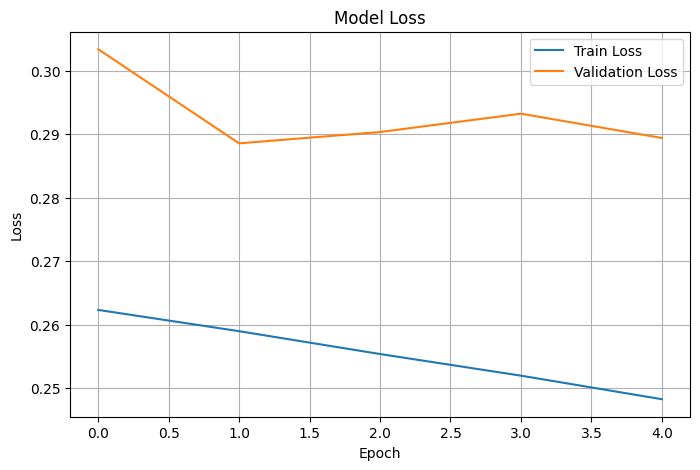

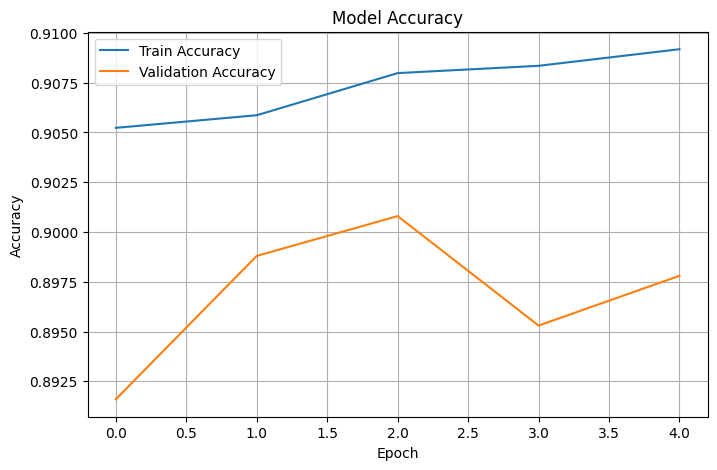

CPU times: total: 3min 9s
Wall time: 2min 48s


In [ ]:
%%time

# Define the callback function
early_stopping = EarlyStopping(patience=3)

# Train the model
history = model.fit(
    train_images,
    train_labels,
    epochs=100,
    batch_size=32,
    validation_data=(test_images, test_labels),
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy = model.evaluate(test_images, test_labels, verbose=0)  # verbose 0 means no output

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training and Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9022 - loss: 0.2914
Test Loss: 0.28943297266960144
Test Accuracy: 0.8978000283241272


In [39]:
# save the  model
# Save the model to be used later
model.save('fashion_mnist_cnn.h5')

Original Shape: (28, 28, 1)
Reshaped Shape: (28, 28, 1)


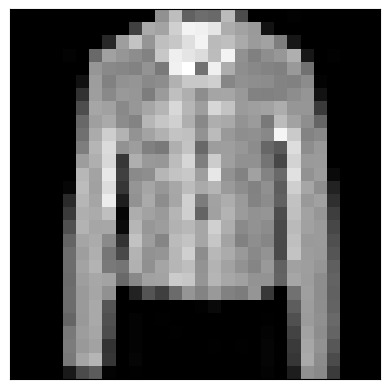

The model predicts that this image is: 4
Actual Label: 4


In [41]:
# Grab an image from the test set
img = test_images[10]
print("Original Shape:", img.shape)

# Reshape the image to (28, 28, 1) if needed
img = img.reshape((28, 28, 1))
print("Reshaped Shape:", img.shape)

# Display the image
plt.imshow(img, cmap="gray")
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()

# Predict the digit
predictions = model.predict(img.reshape(1, 28, 28, 1), verbose=0)

print(f"The model predicts that this image is: {predictions.argmax()}")
print(f"Actual Label: {test_labels[10]}")